<a href="https://colab.research.google.com/github/Demi-Khaled/.Net/blob/main/Oxford_Pet_UNet_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Oxford-IIIT Pet Segmentation with U-Net

Standalone U-Net notebook with automatic results download.

# 🐾 Object Detection & Semantic Segmentation
## Oxford-IIIT Pet Dataset — YOLOv11 vs U-Net

This notebook implements and compares:
- **YOLOv11** — Object Detection (bounding boxes)
- **U-Net** — Semantic Segmentation (pixel-wise masks)

---

## 0. Install Dependencies

In [1]:
!pip install ultralytics torch torchvision torchaudio --quiet
!pip install opencv-python-headless matplotlib scikit-learn tqdm albumentations --quiet
!pip install torchmetrics Pillow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.7 MB/s eta 0:00:00


## 1. Imports & Configuration

In [2]:
import os
import random
import shutil
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import precision_score, recall_score, accuracy_score
from ultralytics import YOLO

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
GPU: Tesla T4


In [3]:
# ── Global Paths & Hyper-parameters ──────────────────────────────────────────
BASE_DIR     = Path('oxford_pet')
IMAGES_DIR   = BASE_DIR / 'images'
MASKS_DIR    = BASE_DIR / 'annotations' / 'trimaps'
XML_DIR      = BASE_DIR / 'annotations' / 'xmls'
YOLO_DIR     = Path('yolo_dataset')
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

IMG_SIZE     = 256     # resize target
BATCH_SIZE   = 16
UNET_EPOCHS  = 30
YOLO_EPOCHS  = 30
LR           = 1e-4
TRAIN_SPLIT  = 0.80
VAL_SPLIT    = 0.10
# TEST = remaining 10 %

NUM_CLASSES  = 37   # 37 pet breeds in Oxford-IIIT
print('Configuration set.')

Configuration set.


## 2. Download the Oxford-IIIT Pet Dataset

In [4]:
import urllib.request
import tarfile

BASE_DIR.mkdir(exist_ok=True)

URLS = {
    'images'     : 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
    'annotations': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz',
}

for name, url in URLS.items():
    dest = BASE_DIR / f'{name}.tar.gz'
    if not dest.exists():
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(url, dest)
    else:
        print(f'{name} archive already exists, skipping download.')

    extract_to = BASE_DIR / name
    if not extract_to.exists():
        print(f'Extracting {name}...')
        with tarfile.open(dest, 'r:gz') as tar:
            tar.extractall(BASE_DIR)
    else:
        print(f'{name} already extracted.')

print('Dataset ready.')
print('Images:    ', len(list(IMAGES_DIR.glob('*.jpg'))))
print('Trimaps:   ', len(list(MASKS_DIR.glob('*.png'))))
print('XML annots:', len(list(XML_DIR.glob('*.xml'))))

Extracting images...


/tmp/ipykernel_3156/1492248863.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(BASE_DIR)


Extracting annotations...
Dataset ready.
Images:     7390
Trimaps:    14780
XML annots: 3686


## 3. Exploratory Data Analysis

/tmp/ipykernel_3156/849506330.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)


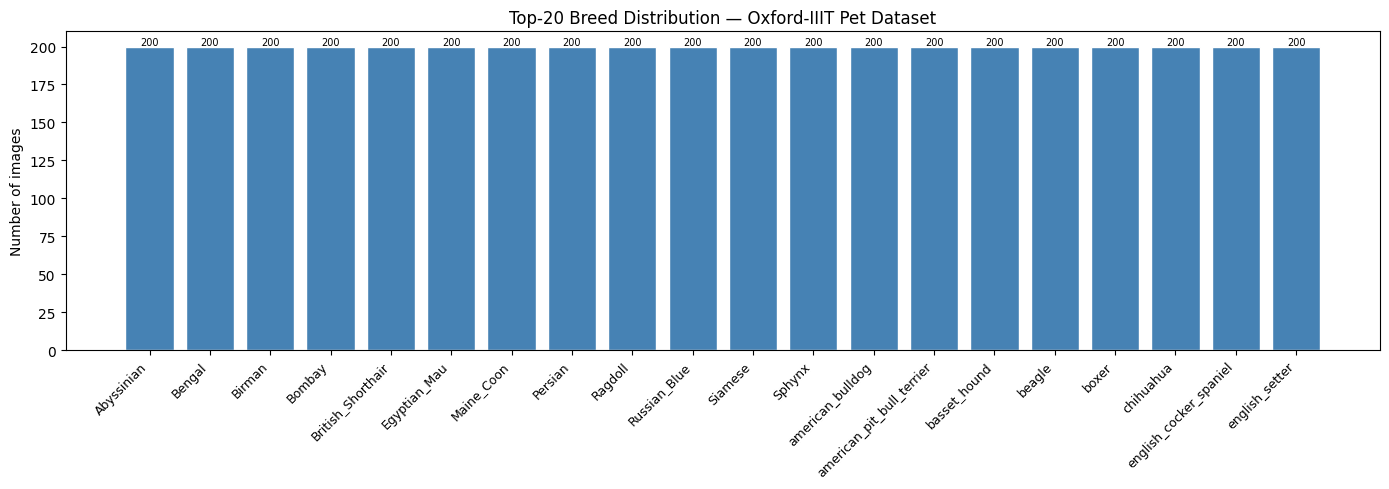

Total images : 7390
Unique breeds: 37


In [5]:
from collections import Counter

# Gather breed names from filenames  (format: Breed_Name_001.jpg)
all_images = sorted(IMAGES_DIR.glob('*.jpg'))
breeds = ['_'.join(p.stem.split('_')[:-1]) for p in all_images]
breed_counts = Counter(breeds)

# Plot top-20 breeds
top20 = breed_counts.most_common(20)
names, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, counts, color='steelblue', edgecolor='white')
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of images')
ax.set_title('Top-20 Breed Distribution — Oxford-IIIT Pet Dataset')
ax.bar_label(bars, fontsize=7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'breed_distribution.png', dpi=150)
plt.show()

print(f'Total images : {len(all_images)}')
print(f'Unique breeds: {len(breed_counts)}')

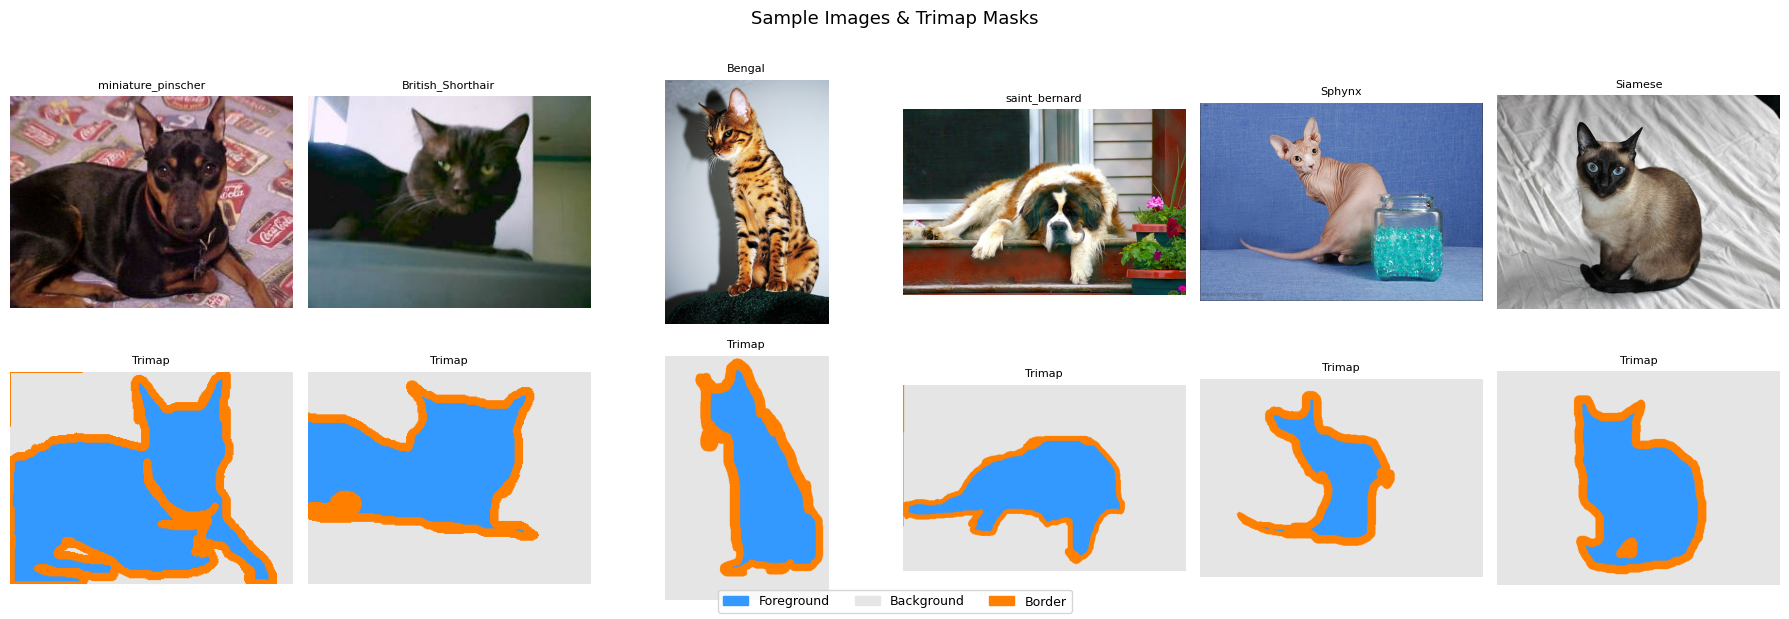

In [6]:
# Visualise sample images + trimap masks
samples = random.sample(all_images, 6)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Trimap legend: 1=foreground, 2=background, 3=border
CMAP = {1: [0.2, 0.6, 1.0], 2: [0.9, 0.9, 0.9], 3: [1.0, 0.5, 0.0]}

for col, img_path in enumerate(samples):
    img = np.array(Image.open(img_path).convert('RGB'))
    mask_path = MASKS_DIR / (img_path.stem + '.png')

    axes[0, col].imshow(img)
    axes[0, col].set_title('_'.join(img_path.stem.split('_')[:-1]), fontsize=8)
    axes[0, col].axis('off')

    if mask_path.exists():
        mask = np.array(Image.open(mask_path))
        coloured = np.zeros((*mask.shape, 3))
        for v, c in CMAP.items():
            coloured[mask == v] = c
        axes[1, col].imshow(coloured)
    else:
        axes[1, col].text(0.5, 0.5, 'No mask', ha='center', va='center')
    axes[1, col].set_title('Trimap', fontsize=8)
    axes[1, col].axis('off')

patches = [mpatches.Patch(color=c, label=l)
           for l, c in zip(['Foreground', 'Background', 'Border'], CMAP.values())]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9)
plt.suptitle('Sample Images & Trimap Masks', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images_masks.png', dpi=150)
plt.show()

## 4. Data Preprocessing
### 4.1 Split Dataset

In [7]:
# Keep only images that have a corresponding trimap mask
valid_images = [p for p in all_images if (MASKS_DIR / (p.stem + '.png')).exists()]
random.shuffle(valid_images)

n = len(valid_images)
n_train = int(n * TRAIN_SPLIT)
n_val   = int(n * VAL_SPLIT)

train_imgs = valid_images[:n_train]
val_imgs   = valid_images[n_train:n_train + n_val]
test_imgs  = valid_images[n_train + n_val:]

print(f'Total valid : {n}')
print(f'Train       : {len(train_imgs)}')
print(f'Validation  : {len(val_imgs)}')
print(f'Test        : {len(test_imgs)}')

Total valid : 7390
Train       : 5912
Validation  : 739
Test        : 739


### 4.2 Augmentation Pipelines

In [8]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),
    A.Rotate(limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print('Augmentation pipelines defined.')

Augmentation pipelines defined.


### 4.3 Dataset Classes

In [9]:
class PetSegmentationDataset(Dataset):
    """Returns (image_tensor, binary_mask) for U-Net training.
    Trimap: 1=foreground → 1, everything else → 0.
    """
    def __init__(self, image_paths, masks_dir, transform=None):
        self.image_paths = image_paths
        self.masks_dir   = Path(masks_dir)
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path  = self.image_paths[idx]
        mask_path = self.masks_dir / (img_path.stem + '.png')

        image = np.array(Image.open(img_path).convert('RGB'))
        mask  = np.array(Image.open(mask_path))   # trimap: 1/2/3
        mask  = (mask == 1).astype(np.uint8)       # binary: pet=1

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].float().unsqueeze(0)

        return image, mask


# Build loaders
train_dataset = PetSegmentationDataset(train_imgs, MASKS_DIR, train_transform)
val_dataset   = PetSegmentationDataset(val_imgs,   MASKS_DIR, val_transform)
test_dataset  = PetSegmentationDataset(test_imgs,  MASKS_DIR, val_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 370
Val   batches: 47
Test  batches: 47


## 5. U-Net Model
### 5.1 Architecture

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)

        # Encoder
        ch = in_channels
        for f in features:
            self.encoder.append(ConvBlock(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # Decoder
        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.decoder.append(ConvBlock(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.decoder), 2):
            x     = self.decoder[i](x)
            skip  = skips[i // 2]
            if x.shape != skip.shape:
                x = TF.resize(x, skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i + 1](x)

        return self.final(x)


unet = UNet().to(DEVICE)
total_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f'U-Net trainable parameters: {total_params:,}')

U-Net trainable parameters: 31,037,633


### 5.2 Loss & Metrics

In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce   = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets)
        probs     = torch.sigmoid(logits)
        num       = 2 * (probs * targets).sum()
        den       = probs.sum() + targets.sum() + self.smooth
        dice_loss = 1 - num / den
        return bce_loss + dice_loss


def compute_metrics(preds, masks, threshold=0.5):
    """Returns IoU, Dice, Accuracy, Precision, Recall over a batch."""
    preds  = (preds > threshold).float()
    smooth = 1e-6

    inter   = (preds * masks).sum()
    union   = preds.sum() + masks.sum() - inter
    iou     = (inter + smooth) / (union + smooth)

    dice    = (2 * inter + smooth) / (preds.sum() + masks.sum() + smooth)

    correct = (preds == masks).float().mean()

    tp = (preds * masks).sum()
    fp = (preds * (1 - masks)).sum()
    fn = ((1 - preds) * masks).sum()

    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)

    return {
        'iou'      : iou.item(),
        'dice'     : dice.item(),
        'accuracy' : correct.item(),
        'precision': precision.item(),
        'recall'   : recall.item(),
    }

print('Loss and metrics defined.')

Loss and metrics defined.


### 5.3 Training Loop

In [12]:
criterion = DiceBCELoss().to(DEVICE)
optimizer = optim.AdamW(unet.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNET_EPOCHS)


def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0
    all_metrics = {k: 0.0 for k in ['iou', 'dice', 'accuracy', 'precision', 'recall']}

    ctx = torch.no_grad() if not training else torch.enable_grad()
    with ctx:
        for images, masks in tqdm(loader, desc='Train' if training else 'Val', leave=False):
            images = images.to(device)
            masks  = masks.to(device)

            logits = model(images)
            loss   = criterion(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            preds = torch.sigmoid(logits).detach()
            m = compute_metrics(preds, masks)
            for k in all_metrics:
                all_metrics[k] += m[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


# ── Train ─────────────────────────────────────────────────────────────────────
unet_history = {'train_loss': [], 'val_loss': [],
                'train_iou': [], 'val_iou': [],
                'train_dice': [], 'val_dice': []}

best_val_iou  = 0.0
best_unet_path = RESULTS_DIR / 'best_unet.pth'

print(f'Starting U-Net training for {UNET_EPOCHS} epochs …')
t0 = time.time()

for epoch in range(1, UNET_EPOCHS + 1):
    tr_loss, tr_m = run_epoch(unet, train_loader, criterion, optimizer)
    vl_loss, vl_m = run_epoch(unet, val_loader,   criterion)
    scheduler.step()

    unet_history['train_loss'].append(tr_loss)
    unet_history['val_loss'].append(vl_loss)
    unet_history['train_iou'].append(tr_m['iou'])
    unet_history['val_iou'].append(vl_m['iou'])
    unet_history['train_dice'].append(tr_m['dice'])
    unet_history['val_dice'].append(vl_m['dice'])

    if vl_m['iou'] > best_val_iou:
        best_val_iou = vl_m['iou']
        torch.save(unet.state_dict(), best_unet_path)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{UNET_EPOCHS} | "
              f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
              f"IoU {tr_m['iou']:.4f}/{vl_m['iou']:.4f} | "
              f"Dice {tr_m['dice']:.4f}/{vl_m['dice']:.4f}")

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s  |  Best Val IoU: {best_val_iou:.4f}')

Starting U-Net training for 30 epochs …


Epoch   1/30 | Loss 0.8351/0.7149 | IoU 0.5509/0.6190 | Dice 0.7061/0.7634


Epoch   5/30 | Loss 0.4051/0.3960 | IoU 0.7505/0.7625 | Dice 0.8567/0.8644


Epoch  10/30 | Loss 0.3207/0.3038 | IoU 0.7982/0.8067 | Dice 0.8872/0.8925


Epoch  15/30 | Loss 0.2588/0.2568 | IoU 0.8346/0.8357 | Dice 0.9094/0.9101


Epoch  20/30 | Loss 0.2194/0.2261 | IoU 0.8583/0.8529 | Dice 0.9234/0.9202


Epoch  25/30 | Loss 0.1938/0.2152 | IoU 0.8739/0.8597 | Dice 0.9324/0.9242


Epoch  30/30 | Loss 0.1848/0.2134 | IoU 0.8798/0.8614 | Dice 0.9358/0.9252

Training complete in 8913.1s  |  Best Val IoU: 0.8617


### 5.4 Training Curves

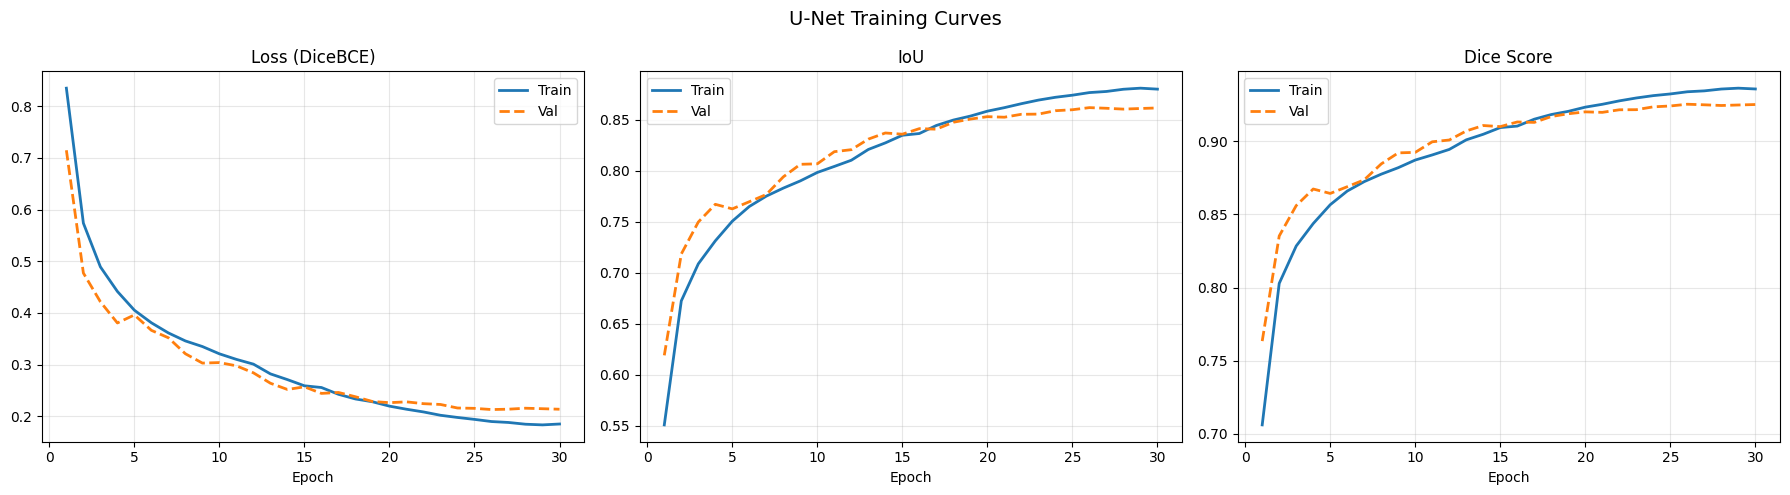

In [13]:
epochs = range(1, UNET_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, key, title in zip(
        axes,
        [('train_loss','val_loss'), ('train_iou','val_iou'), ('train_dice','val_dice')],
        ['Loss (DiceBCE)', 'IoU', 'Dice Score']):
    ax.plot(epochs, unet_history[key[0]], label='Train', linewidth=2)
    ax.plot(epochs, unet_history[key[1]], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('U-Net Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'unet_training_curves.png', dpi=150)
plt.show()

### 5.5 U-Net Evaluation on Test Set

In [14]:
# Load best checkpoint
unet.load_state_dict(torch.load(best_unet_path, map_location=DEVICE))
unet.eval()

test_loss, test_m = run_epoch(unet, test_loader, criterion)

print('\n── U-Net Test Results ──────────────────────')
print(f"  Loss      : {test_loss:.4f}")
for k, v in test_m.items():
    print(f"  {k.capitalize():<12}: {v:.4f}")


── U-Net Test Results ──────────────────────
  Loss      : 0.2248
  Iou         : 0.8566
  Dice        : 0.9225
  Accuracy    : 0.9522
  Precision   : 0.9055
  Recall      : 0.9407


### 5.6 Segmentation Visualisation

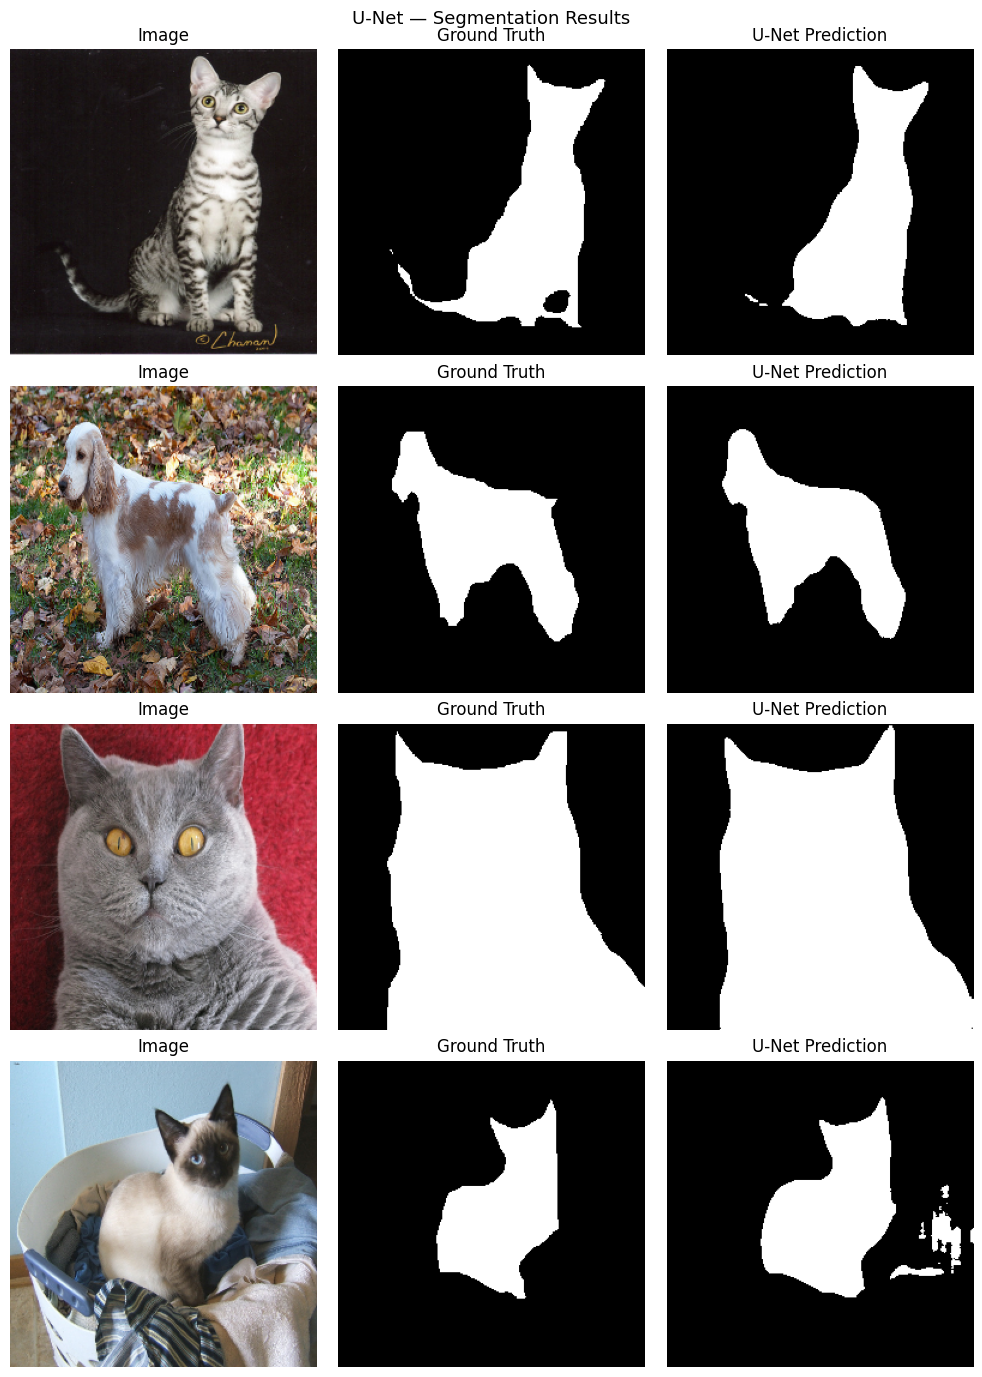

In [15]:
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

unet.eval()
images_b, masks_b = next(iter(test_loader))
with torch.no_grad():
    preds_b = torch.sigmoid(unet(images_b.to(DEVICE))).cpu()

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.5 * n_show))

for row in range(n_show):
    img  = denorm(images_b[row])
    mask = masks_b[row, 0].numpy()
    pred = (preds_b[row, 0].numpy() > 0.5).astype(float)

    axes[row, 0].imshow(img);  axes[row, 0].set_title('Image')
    axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title('Ground Truth')
    axes[row, 2].imshow(pred, cmap='gray'); axes[row, 2].set_title('U-Net Prediction')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('U-Net — Segmentation Results', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'unet_predictions.png', dpi=150)
plt.show()

In [16]:
# Auto-download U-Net results
import shutil
from google.colab import files

UNET_OUTPUT_DIR = "unet_results_package"

# Create package directory
shutil.rmtree(UNET_OUTPUT_DIR, ignore_errors=True)
shutil.copytree("results", UNET_OUTPUT_DIR)

# Zip folder
archive_path = shutil.make_archive("UNet_Results", 'zip', UNET_OUTPUT_DIR)

print(f"Created: {archive_path}")

# Download automatically
files.download(archive_path)


Created: /content/UNet_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>